# Perbandingan Kinerja Multilayer Perceptron (MLP) dan Random Forest dalam Klasifikasi Kanker Payudara Menggunakan Dataset Breast Cancer Wisconsin

 # Latar Belakang

Kanker payudara merupakan salah satu jenis kanker yang paling banyak dialami oleh perempuan dan menjadi penyebab utama kematian akibat kanker di berbagai negara. Deteksi dini dan diagnosis yang akurat sangat penting untuk meningkatkan peluang keberhasilan pengobatan serta mengurangi risiko komplikasi yang lebih serius. Namun, proses diagnosis secara manual membutuhkan waktu dan ketelitian tinggi karena harus menganalisis berbagai karakteristik sel yang diperoleh dari hasil pemeriksaan medis.


Perkembangan teknologi pembelajaran mesin (machine learning) memungkinkan proses klasifikasi penyakit dilakukan secara lebih cepat dan objektif berdasarkan data historis yang tersedia. Salah satu dataset yang banyak digunakan dalam penelitian klasifikasi kanker payudara adalah Breast Cancer Wisconsin Dataset, yang berisi berbagai atribut karakteristik sel untuk menentukan apakah suatu tumor termasuk kategori benign (jinak) atau malignant (ganas).


Dalam penelitian ini digunakan dua algoritma klasifikasi yang memiliki karakteristik berbeda, yaitu Multilayer Perceptron (MLP) yang merupakan metode berbasis jaringan saraf tiruan, dan Random Forest yang merupakan metode ensemble learning berbasis kumpulan decision tree. Kedua algoritma tersebut dipilih karena memiliki kemampuan yang baik dalam menangani permasalahan klasifikasi dan sering digunakan pada bidang kesehatan. Oleh karena itu, penelitian ini dilakukan untuk membandingkan kinerja MLP dan Random Forest dalam mengklasifikasikan kanker payudara menggunakan Breast Cancer Wisconsin Dataset berdasarkan metrik evaluasi Accuracy, Precision, Recall, F1-Score, Classification Report, dan Confusion Matrix.


# Tujuan

1. Mengolah dan mempersiapkan Breast Cancer Wisconsin Dataset untuk proses klasifikasi kanker payudara.


2. Membangun model klasifikasi menggunakan algoritma Multilayer Perceptron (MLP) dan Random Forest.


3. Melatih kedua model menggunakan data latih yang telah diproses.


4. Mengevaluasi performa model MLP dan Random Forest menggunakan metrik Accuracy, Precision, Recall, F1-Score, Classification Report, dan Confusion Matrix.


5. Membandingkan hasil kinerja kedua algoritma untuk menentukan model yang memberikan performa terbaik dalam klasifikasi kanker payudara pada dataset yang digunakan.


6. Memberikan rekomendasi algoritma yang lebih efektif berdasarkan hasil pengujian dan evaluasi model.



# Import Library

In [12]:
import pandas as pd
import numpy as np

# Pembagian data
from sklearn.model_selection import train_test_split

# Normalisasi data
from sklearn.preprocessing import StandardScaler

# Model Machine Learning
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

# Evaluasi
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import SMOTE

# Load Dataset

In [13]:
df = pd.read_excel('dataset_breast_cancer_wisconsin.xlsx')

# Data Understanding

Menampilkan shape, info(), describe(), distribusi kelas, dan pengecekan missing value

In [14]:
# Shape
print("Shape Dataset:")
print(df.shape)

Shape Dataset:
(699, 11)


In [15]:
df

,Sample_Code_Number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bare_Nuclei,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
...,...,...,...,...,...,...,...,...,...,...,...
694,776715,3,1,1,1,3,2,1,1,1,2
695,841769,2,1,1,1,2,1,1,1,1,2
696,888820,5,10,10,3,7,3,8,10,2,4
697,897471,4,8,6,4,3,4,10,6,1,4


In [16]:
# info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Sample_Code_Number           699 non-null    int64 
 1   Clump_Thickness              699 non-null    int64 
 2   Uniformity_of_Cell_Size      699 non-null    int64 
 3   Uniformity_of_Cell_Shape     699 non-null    int64 
 4   Marginal_Adhesion            699 non-null    int64 
 5   Single_Epithelial_Cell_Size  699 non-null    int64 
 6   Bare_Nuclei                  699 non-null    object
 7   Bland_Chromatin              699 non-null    int64 
 8   Normal_Nucleoli              699 non-null    int64 
 9   Mitoses                      699 non-null    int64 
 10  Class                        699 non-null    int64 
dtypes: int64(10), object(1)
memory usage: 60.2+ KB


In [17]:
# describe
df.describe()

,Sample_Code_Number,Clump_Thickness,Uniformity_of_Cell_Size,Uniformity_of_Cell_Shape,Marginal_Adhesion,Single_Epithelial_Cell_Size,Bland_Chromatin,Normal_Nucleoli,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


Distribusi Kelas:
Class
Jinak (Benign)       458
Ganas (Malignant)    241
Name: count, dtype: int64

Persentase:
Class
Jinak (Benign)       65.52%
Ganas (Malignant)    34.48%
Name: count, dtype: object


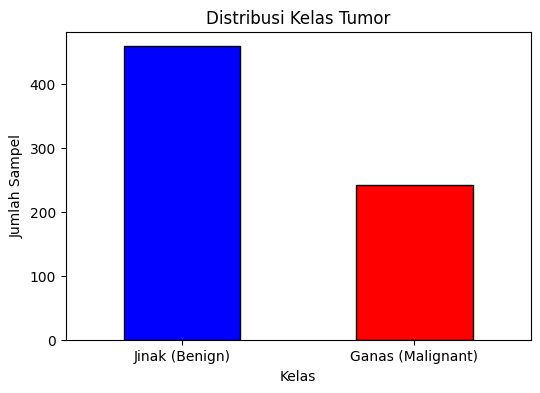

In [18]:
# Distribusi kelas
class_labels = {2: 'Jinak (Benign)', 4: 'Ganas (Malignant)'}

class_dist = df['Class'].value_counts()
class_dist.index = class_dist.index.map(class_labels)

print("Distribusi Kelas:")
print(class_dist)

print("\nPersentase:")
print((class_dist / len(df) * 100).round(2).astype(str) + '%')

# Visualisasi
plt.figure(figsize=(6,4))

colors = ['blue', 'red']

class_dist.plot(
    kind='bar',
    color=colors,
    edgecolor='black'
)

plt.title('Distribusi Kelas Tumor')
plt.xlabel('Kelas')
plt.ylabel('Jumlah Sampel')
plt.xticks(rotation=0)

plt.show()

In [19]:
# Missing Value
print("Missing Value (NaN):")
print(df.isnull().sum())

print("\nJumlah nilai '?' per kolom:")
print((df == '?').sum())

Missing Value (NaN):
Sample_Code_Number             0
Clump_Thickness                0
Uniformity_of_Cell_Size        0
Uniformity_of_Cell_Shape       0
Marginal_Adhesion              0
Single_Epithelial_Cell_Size    0
Bare_Nuclei                    0
Bland_Chromatin                0
Normal_Nucleoli                0
Mitoses                        0
Class                          0
dtype: int64

Jumlah nilai '?' per kolom:
Sample_Code_Number              0
Clump_Thickness                 0
Uniformity_of_Cell_Size         0
Uniformity_of_Cell_Shape        0
Marginal_Adhesion               0
Single_Epithelial_Cell_Size     0
Bare_Nuclei                    16
Bland_Chromatin                 0
Normal_Nucleoli                 0
Mitoses                         0
Class                           0
dtype: int64


# Data Preprocessing

Langkah: hapus kolom `Sample_Code_Number`, tangani missing, ubah label, pisahkan fitur-target, normalisasi

In [20]:
# Hapus kolom Sample_Code_Number
df = df.drop('Sample_Code_Number', axis=1)

# Tangani missing value (nilai '?')
df = df.replace('?', np.nan)
df = df.dropna()

df = df.astype(int)

print(f"Shape dataset setelah preprocessing: {df.shape}")

# Ubah label kelas dari 2,4 menjadi 0,1
df['Class'] = df['Class'].map({2: 0, 4: 1})

print("\nDistribusi kelas setelah mapping:")
print(df['Class'].value_counts().sort_index())

# Pisahkan fitur (X) dan target (y)
X = df.drop('Class', axis=1)
y = df['Class']

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")

# Normalisasi data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Shape dataset setelah preprocessing: (683, 10)

Distribusi kelas setelah mapping:
Class
0    444
1    239
Name: count, dtype: int64

Shape X: (683, 9)
Shape y: (683,)


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 683 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Clump_Thickness              683 non-null    int64
 1   Uniformity_of_Cell_Size      683 non-null    int64
 2   Uniformity_of_Cell_Shape     683 non-null    int64
 3   Marginal_Adhesion            683 non-null    int64
 4   Single_Epithelial_Cell_Size  683 non-null    int64
 5   Bare_Nuclei                  683 non-null    int64
 6   Bland_Chromatin              683 non-null    int64
 7   Normal_Nucleoli              683 non-null    int64
 8   Mitoses                      683 non-null    int64
 9   Class                        683 non-null    int64
dtypes: int64(10)
memory usage: 58.7 KB


# Data Splitting

Gunakan 80% training dan 20% testing, `random_state=42`

In [22]:
# Pembagian data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=7,
    stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print(f"\nTraining: {len(X_train) / len(X_scaled) * 100:.2f}%")
print(f"Testing: {len(X_test) / len(X_scaled) * 100:.2f}%")

print("\nDistribusi kelas training:")
print(y_train.value_counts().sort_index())

print("\nDistribusi kelas testing:")
print(y_test.value_counts().sort_index())


X_train shape: (546, 9)
X_test shape: (137, 9)
y_train shape: (546,)
y_test shape: (137,)

Training: 79.94%
Testing: 20.06%

Distribusi kelas training:
Class
0    355
1    191
Name: count, dtype: int64

Distribusi kelas testing:
Class
0    89
1    48
Name: count, dtype: int64


In [23]:
# MLP Tanpa SMOTE

mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=1000,
    random_state=43
)

mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy : 0.9854014598540146
Precision: 0.96
Recall   : 1.0
F1 Score : 0.9795918367346939
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        89
           1       0.96      1.00      0.98        48

    accuracy                           0.99       137
   macro avg       0.98      0.99      0.98       137
weighted avg       0.99      0.99      0.99       137



In [24]:
# Random Forest Tanpa SMOTE

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=43
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.9781021897810219
Precision: 0.9411764705882353
Recall   : 1.0
F1 Score : 0.9696969696969697
              precision    recall  f1-score   support

           0       1.00      0.97      0.98        89
           1       0.94      1.00      0.97        48

    accuracy                           0.98       137
   macro avg       0.97      0.98      0.98       137
weighted avg       0.98      0.98      0.98       137



In [25]:
# Balancing menggunakan SMOTE

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=7)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

print("Distribusi sebelum SMOTE:")
print(y_train.value_counts())

print("\nDistribusi setelah SMOTE:")
print(y_train_smote.value_counts())

Distribusi sebelum SMOTE:
Class
0    355
1    191
Name: count, dtype: int64

Distribusi setelah SMOTE:
Class
0    355
1    355
Name: count, dtype: int64


# Pembangunan Model MLP dan Random Forest

Spesifikasi model MLP sesuai permintaan: `hidden_layer_sizes=(10,)`, `activation='relu'`, `max_iter=1000`, `random_state=43`.

Singkat: Input layer (fitur), Hidden layer (neuron tersembunyi), Output layer (kelas), Backpropagation untuk update bobot.
Untuk Random Forest, model ensemble berbasis beberapa decision tree digunakan sebagai pembanding.

In [26]:
mlp = MLPClassifier(
    hidden_layer_sizes=(10,),
    activation='relu',
    max_iter=1000,
    random_state=43
)

Setelah membangun model MLP, penelitian ini juga menggunakan Random Forest sebagai model pembanding. Random Forest merupakan metode ensemble yang menggabungkan banyak decision tree untuk meningkatkan akurasi klasifikasi dan mengurangi overfitting. Model dibangun dengan parameter n_estimators=100 dan random_state=43.

In [27]:
# Membangun model Random Forest

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=43
)

print(rf)

RandomForestClassifier(random_state=43)


Training Model

In [28]:
# Training MLP

mlp.fit(X_train_smote, y_train_smote)

print("Training MLP selesai")


# Training Random Forest

rf.fit(X_train_smote, y_train_smote)

print("Training Random Forest selesai")

Training MLP selesai
Training Random Forest selesai


Testing

In [29]:
y_pred_mlp = mlp.predict(X_test)
y_pred_rf = rf.predict(X_test)

Evaluasi Model

In [30]:
print("Accuracy :", accuracy_score(y_test, y_pred_mlp))
print("Precision:", precision_score(y_test, y_pred_mlp))
print("Recall   :", recall_score(y_test, y_pred_mlp))
print("F1 Score :", f1_score(y_test, y_pred_mlp))

Accuracy : 0.9854014598540146
Precision: 0.96
Recall   : 1.0
F1 Score : 0.9795918367346939


Perbandingan Model

In [31]:
hasil = pd.DataFrame({
    'Model': ['MLP', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_mlp),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_mlp),
        recall_score(y_test, y_pred_rf)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_mlp),
        f1_score(y_test, y_pred_rf)
    ]
})

hasil

,Model,Accuracy,Precision,Recall,F1-Score
0,MLP,0.985401,0.960000,1.0,0.979592
1,Random Forest,0.978102,0.941176,1.0,0.969697


In [32]:
# Classification Report
print("Classification Report MLP : ")
print(classification_report(y_test, y_pred_mlp, target_names=['Jinak (Benign)', 'Ganas (Malignant)']))

print(" Classification Report Random Forest : ")
print(classification_report(y_test, y_pred_rf, target_names=['Jinak (Benign)', 'Ganas (Malignant)']))

Classification Report MLP : 
                   precision    recall  f1-score   support

   Jinak (Benign)       1.00      0.98      0.99        89
Ganas (Malignant)       0.96      1.00      0.98        48

         accuracy                           0.99       137
        macro avg       0.98      0.99      0.98       137
     weighted avg       0.99      0.99      0.99       137

 Classification Report Random Forest : 
                   precision    recall  f1-score   support

   Jinak (Benign)       1.00      0.97      0.98        89
Ganas (Malignant)       0.94      1.00      0.97        48

         accuracy                           0.98       137
        macro avg       0.97      0.98      0.98       137
     weighted avg       0.98      0.98      0.98       137



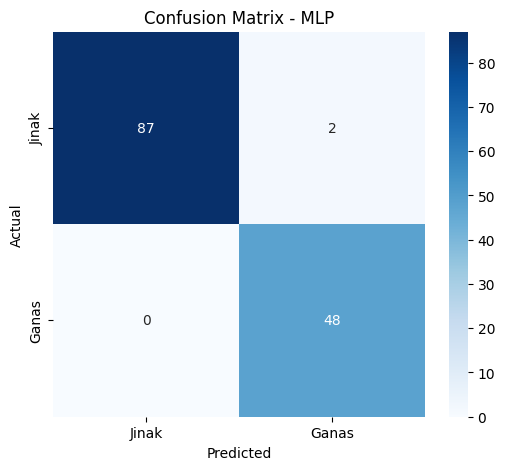

In [33]:
# Confusion Matrix MLP
plt.figure(figsize=(6, 5))
cm_mlp = confusion_matrix(y_test, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Jinak', 'Ganas'],
            yticklabels=['Jinak', 'Ganas'])
plt.title('Confusion Matrix - MLP')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

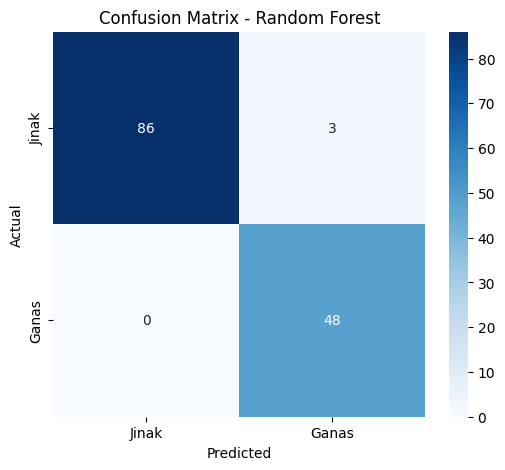

In [34]:
# Confusion Matrix Random Forest
plt.figure(figsize=(6, 5))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Jinak', 'Ganas'],
            yticklabels=['Jinak', 'Ganas'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

Hasil dan Kesimpulan

Penelitian ini berhasil membangun model deteksi dini kanker payudara menggunakan algoritma Multilayer Perceptron (MLP) pada Dataset Breast Cancer Wisconsin untuk mengklasifikasikan tumor jinak (*benign*) dan ganas (*malignant*). Penelitian juga membandingkan performa model sebelum dan sesudah penerapan teknik balancing menggunakan Synthetic Minority Oversampling Technique (SMOTE), serta membandingkannya dengan algoritma Random Forest.

Berdasarkan hasil pengujian, model MLP tanpa SMOTE memperoleh nilai Accuracy sebesar **98,54%**, Precision **96,00%**, Recall **100,00%**, dan F1-Score **97,96%**. Setelah diterapkan SMOTE, nilai Accuracy, Precision, Recall, dan F1-Score tetap sebesar **98,54%**, **96,00%**, **100,00%**, dan **97,96%**.

Model Random Forest tanpa SMOTE menghasilkan Accuracy sebesar **97,81%**, Precision **94,12%**, Recall **100,00%**, dan F1-Score **96,97%**. Setelah penerapan SMOTE, performa model juga tidak mengalami perubahan dengan nilai Accuracy **97,81%**, Precision **94,12%**, Recall **100,00%**, dan F1-Score **96,97%**.

Hasil perbandingan menunjukkan bahwa model MLP memiliki performa lebih baik dibandingkan Random Forest pada seluruh metrik evaluasi. Selain itu, penerapan SMOTE tidak memberikan peningkatan performa pada kedua model. Kondisi ini menunjukkan bahwa distribusi kelas pada Dataset Breast Cancer Wisconsin sudah cukup seimbang sehingga model mampu mempelajari pola data dengan baik meskipun tanpa proses balancing.

Berdasarkan hasil penelitian, algoritma Multilayer Perceptron (MLP) menjadi model dengan performa terbaik untuk deteksi dini kanker payudara pada Dataset Breast Cancer Wisconsin dengan nilai Accuracy **98,54%**, Precision **96,00%**, Recall **100,00%**, dan F1-Score **97,96%**.
